<a href="https://colab.research.google.com/github/Emushame/ML_BAC4_UMK/blob/main/prediction_culture_agricole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importation de librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from warnings import filterwarnings
filterwarnings('ignore')

# 2. Charger les donnees

In [3]:
PATH = "data/dataset_etat_culture.xlsx"
df = pd.read_excel(PATH)
df.head()

,humidite_sol,pluviometrie,temperature,niveau_azote,couleur_feuilles,taches_feuilles,croissance,etat_culture
0,62,45,28,7,Vert,0,Élevée,0
1,24,18,35,6,Jaune,0,Faible,1
2,58,60,26,4,Jaune,0,Moyenne,2
3,65,55,24,8,Vert,1,Moyenne,3
4,70,75,22,9,Vert,0,Élevée,0


In [4]:
df.shape

(541, 8)

# 3. Analyser les donnees

## 3.1 verifier la structure du dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   humidite_sol      541 non-null    int64 
 1   pluviometrie      541 non-null    int64 
 2   temperature       541 non-null    int64 
 3   niveau_azote      541 non-null    int64 
 4   couleur_feuilles  541 non-null    object
 5   taches_feuilles   541 non-null    int64 
 6   croissance        541 non-null    object
 7   etat_culture      541 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 33.9+ KB


## 3.2 verifier les valeurs manquantes

In [6]:
print("affichage de valeurs manquantes")
df.isna().sum()

affichage de valeurs manquantes


,0
humidite_sol,0
pluviometrie,0
temperature,0
niveau_azote,0
couleur_feuilles,0
taches_feuilles,0
croissance,0
etat_culture,0


## 3.3 verifier la distribution des classes (variable cible)

In [7]:
df['etat_culture'].value_counts()

,count
etat_culture,
0,136
1,135
2,135
3,135


## 3.4 verifier la distribution des classes (variable cible) en %

In [10]:
df['etat_culture'].value_counts(normalize=True) * 100

,proportion
etat_culture,
0,25.138632
1,24.953789
2,24.953789
3,24.953789


## 3.5 afficher les statistiques descriptives

In [11]:
df.describe()

,humidite_sol,pluviometrie,temperature,niveau_azote,taches_feuilles,etat_culture
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,59.295749,65.210721,15.957486,6.101664,0.249538,1.497227
std,19.018737,21.938381,10.595599,2.022745,0.433146,1.119892
min,22.000000,18.000000,0.000000,2.000000,0.000000,0.000000
25%,44.000000,48.000000,8.000000,5.000000,0.000000,0.000000
50%,57.000000,68.000000,15.000000,7.000000,0.000000,1.000000
75%,75.000000,81.000000,23.000000,8.000000,0.000000,2.000000
max,101.000000,111.000000,51.000000,9.000000,1.000000,3.000000


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
humidite_sol,541.0,59.295749,19.018737,22.0,44.0,57.0,75.0,101.0
pluviometrie,541.0,65.210721,21.938381,18.0,48.0,68.0,81.0,111.0
temperature,541.0,15.957486,10.595599,0.0,8.0,15.0,23.0,51.0
niveau_azote,541.0,6.101664,2.022745,2.0,5.0,7.0,8.0,9.0
taches_feuilles,541.0,0.249538,0.433146,0.0,0.0,0.0,0.0,1.0
etat_culture,541.0,1.497227,1.119892,0.0,0.0,1.0,2.0,3.0


# 4. Pretraitement des donnees

## 4.1 nettoyage simple des valeurs categorielles

In [15]:
# nettoyage simple
df['couleur_feuilles'] = df['couleur_feuilles'].astype(str)
df['couleur_feuilles'] = df['couleur_feuilles'].str.strip().str.title()
df['croissance'] = df['croissance'].astype(str)
df['croissance'] = df['croissance'].str.strip().str.title()

def normalize_yes_no(x):
    if pd.isna(x):
        return x
    s = str(x).strip().lower()
    if s in ['oui', 'o', 'yes', 'y']:
      return 'oui'
    elif s in ['non', 'n', 'no']:
      return 'non'
    return str(x).strip().title()
df['taches_feuilles'] = df['taches_feuilles'].apply(normalize_yes_no)

# verifier les categories
print("Couleur des feuilles")
print(df['couleur_feuilles'].unique())
print("Croissance")
print(df['croissance'].unique)
print("Taches des feuilles")
print(df['taches_feuilles'].unique())

Couleur des feuilles
['Vert' 'Jaune' 'Brun']
Croissance
<bound method Series.unique of 0       Élevée
1       Faible
2      Moyenne
3      Moyenne
4       Élevée
        ...   
536     Élevée
537     Faible
538     Faible
539    Moyenne
540     Élevée
Name: croissance, Length: 541, dtype: object>
Taches des feuilles
['0' '1']


## 4.2 encodage

In [16]:
df_encoded = pd.get_dummies(df
                            , columns=['couleur_feuilles', 'croissance', 'taches_feuilles']
                            , drop_first=True)
df_encoded.head()

,humidite_sol,pluviometrie,temperature,niveau_azote,etat_culture,couleur_feuilles_Jaune,couleur_feuilles_Vert,croissance_Moyenne,croissance_Élevée,taches_feuilles_1
0,62,45,28,7,0,False,True,False,True,False
1,24,18,35,6,1,True,False,False,False,False
2,58,60,26,4,2,True,False,True,False,False
3,65,55,24,8,3,False,True,True,False,True
4,70,75,22,9,0,False,True,False,True,False


## 4.3 Convertir bool -> int (True/False)

In [17]:
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)
df_encoded.head()

,humidite_sol,pluviometrie,temperature,niveau_azote,etat_culture,couleur_feuilles_Jaune,couleur_feuilles_Vert,croissance_Moyenne,croissance_Élevée,taches_feuilles_1
0,62,45,28,7,0,0,1,0,1,0
1,24,18,35,6,1,1,0,0,0,0
2,58,60,26,4,2,1,0,1,0,0
3,65,55,24,8,3,0,1,1,0,1
4,70,75,22,9,0,0,1,0,1,0


## 4.4 Afficher la matrice de correlation

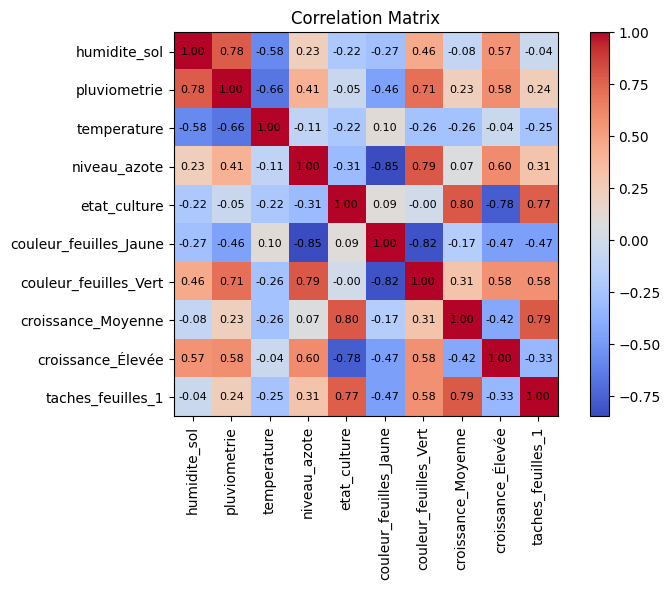

In [43]:
corr_matrix = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

#ajouter les valeurs
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        plt.text(j, i, s=f"{val:.2f}", ha='center', va='center', fontsize=8)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# 5. Diviser les donnees : Train et Test

In [24]:
X = df_encoded.drop('etat_culture', axis=1)
y = df_encoded['etat_culture']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42, stratify=y)

print("Taille de X_train :", X_train.shape)
print("Taille de y_train :", y_train.shape)

print("Distribution de y_train :")
print(y_train.value_counts())

print("Distribution de y_test :")
print(y_test.value_counts())

Taille de X_train : (432, 9)
Taille de y_train : (432,)
Distribution de y_train :
etat_culture
1    108
3    108
2    108
0    108
Name: count, dtype: int64
Distribution de y_test :
etat_culture
0    28
1    27
3    27
2    27
Name: count, dtype: int64


# 6. Construire le modele de Machine learning

## 6.1 Creation du modele de regression logistique (multiclasse)

In [26]:
log_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000)
log_multi.fit(X_train, y_train)

LogisticRegression(max_iter=2000, multi_class='multinomial')

In [27]:
y_pred_log = log_multi.predict(X_test)

## 6.2 creation du modele decision tree

In [28]:
mod_decision_tree = DecisionTreeClassifier()
mod_decision_tree.fit(X_train, y_train)


DecisionTreeClassifier()

In [29]:
y_pred_decision_tree = mod_decision_tree.predict(X_test)

## 6.3 creation du modele RF (Random Forest)

In [30]:
mod_rf = RandomForestClassifier()
mod_rf.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
y_pred_rf = mod_rf.predict(X_test)

## 6.4. creation du modele K-plus proches voisins (KNN)

In [32]:
mod_knn = KNeighborsClassifier()
mod_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [33]:
y_pred_knn = mod_knn.predict(X_test)

# 7. Visualiser l'evolution de l'entrainement

In [36]:
# learning curve
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(estimator=log_multi, X=X_train, y=y_train)


# 8. Evaluer les modeles

## 8.1 Evaluer le modele de regression logistique (multiclasse)

In [39]:
print("Classification report :")
print(classification_report(y_test, y_pred_log))


Classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        27

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109



## 8.2 Evaluer le modele decision tree

In [40]:
print("Classification report :")
print(classification_report(y_test, y_pred_decision_tree))

Classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        27

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109



## 8.3 Evaluer le modele RF

In [41]:
print("Classification report :")
print(classification_report(y_test, y_pred_rf))

Classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        27

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109



## 8.4 Evaluer le modele KNN

In [42]:
print("Classification report :")
print(classification_report(y_test, y_pred_knn))

Classification report :
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        28
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        27
           3       1.00      0.93      0.96        27

    accuracy                           0.98       109
   macro avg       0.98      0.98      0.98       109
weighted avg       0.98      0.98      0.98       109



# 9. Exporter le meilleur modele